# Leland Model: Visualization
## ABM + Monte Carlo Results

This notebook visualizes results from the Leland hedging model:
- Agent-Based Model (ABM) with real market data
- Monte Carlo simulation
- Comparison of Black-Scholes vs Leland strategies

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Project modules
from config import config
from model_abm import run_abm
from model_monte_carlo import run_monte_carlo
from analysis import analyze_abm_results, analyze_mc_results, compare_abm_vs_mc

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ Libraries loaded")

✓ Libraries loaded


## 1. Configuration

In [2]:
# Display configuration
config.display()


PROJECT CONFIGURATION

Data:
  Ticker:              AAPL
  Period:              2021-01-01 to 2023-12-31
  Duration:            ~2 years

Option:
  Time to maturity:    1.0 year
  Risk-free rate:      5.00%
  Strike offset:       +0.0%

Transaction Costs:
  k coefficient:       1.00%

Rebalancing:
  Frequency:           Every 5 days

Agents:
  Fundamentalists:     9
    - Low aggr.:       3 (a=0.02)
    - Medium aggr.:    3 (a=0.05)
    - High aggr.:      3 (a=0.1)
  NoiseTraders:        5
  MarketMakers:        2 (BS + Leland)

Monte Carlo:
  Simulations:         50,000



## 2. Run Simulations

In [3]:
# Run ABM with real data
print("Running ABM...")
abm_results, market_data = run_abm(config)
analyze_abm_results(abm_results)

Running ABM...

📊 Downloading AAPL data...
   Period: 2021-01-01 to 2023-12-31
✓ Downloaded 753 days
   Price range: $113.44 - $196.26
   Realized volatility: 27.75%
   Realized drift: 13.90%


✓ ABM Model created
   Total agents: 16
   Simulation days: 752

Initializing ABM...
  ✓ Black-Scholes MM sold option for $16.85
  ✓ Leland MM sold option for $16.85
  ✓ Strike price: $125.97

Running ABM on real 125.97 → 190.73 data...
Progress: 50...100...150...200...250...300...350...400...450...500...550...600...650...700...750...752 Done!

Finalizing (option expiration)...
✓ Final stock price: $190.73
✓ Option payoff: $64.75

                    ABM RESULTS ANALYSIS

Market:
  Ticker:            AAPL
  Initial price:     $125.97
  Final price:       $190.73
  Price change:      +51.40%
  Strike (K):        $125.97
  Option payoff:     $64.75

Strategy             Final P&L       Trans. Costs    # Hedges  
----------------------------------------------------------------------
BlackScholes   

In [4]:
# Run Monte Carlo
print("Running Monte Carlo...")
initial_price = market_data['prices'][0]
strike = abm_results['strike']
volatility = market_data['volatility']

mc_results = run_monte_carlo(config, initial_price, strike, volatility)
analyze_mc_results(mc_results)

Running Monte Carlo...

MONTE CARLO SIMULATION

Parameters:
  Initial Price (S0): $125.97
  Strike (K):         $125.97
  Volatility (σ):     27.75%
  Time to Maturity:   1.0 year
  Transaction Cost:   1.00%
  Simulations:        50,000
  Steps per path:     252

Running simulations...
  Completed 10,000/50,000
  Completed 20,000/50,000
  Completed 30,000/50,000
  Completed 40,000/50,000
  Completed 50,000/50,000
✓ Monte Carlo complete!


                    MONTE CARLO RESULTS

Simulation Parameters:
  Initial Price:     $125.97
  Strike:            $125.97
  Volatility:        27.75%

Strategy             Mean P&L        Std Dev         Avg Trans Cost 
----------------------------------------------------------------------
BlackScholes         $  -24.91      $    2.54      $    7.00
Leland               $  -23.89      $    0.92      $    6.02
----------------------------------------------------------------------

Improvement (Leland vs BS):
  Better return:    $    1.02 (+4.1%)
  Risk

## 3. Visualizations

### 3.1 Stock Price Evolution (Real Data)

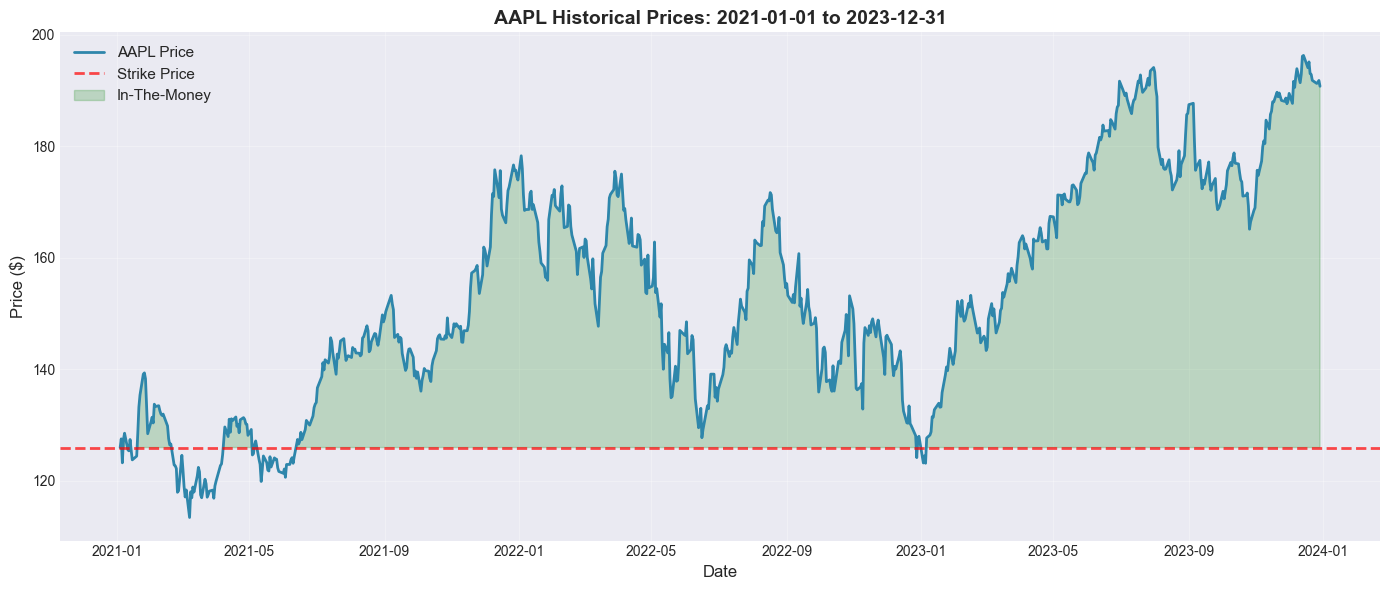

Price change: +51.40%


In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

# Plot real prices
ax.plot(market_data['dates'], abm_results['real_prices'], 
        linewidth=2, color='#2E86AB', label=f"{config.ticker} Price")

# Strike line
ax.axhline(y=abm_results['strike'], color='red', linestyle='--', 
          linewidth=2, alpha=0.7, label='Strike Price')

# ITM region
ax.fill_between(market_data['dates'], abm_results['strike'], 
               abm_results['real_prices'],
               where=(abm_results['real_prices'] > abm_results['strike']),
               alpha=0.2, color='green', label='In-The-Money')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price ($)', fontsize=12)
ax.set_title(f'{config.ticker} Historical Prices: {config.start_date} to {config.end_date}', 
            fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Price change: {(abm_results['final_price']/abm_results['real_prices'][0] - 1)*100:+.2f}%")

### 3.2 ABM: Market Maker P&L Comparison

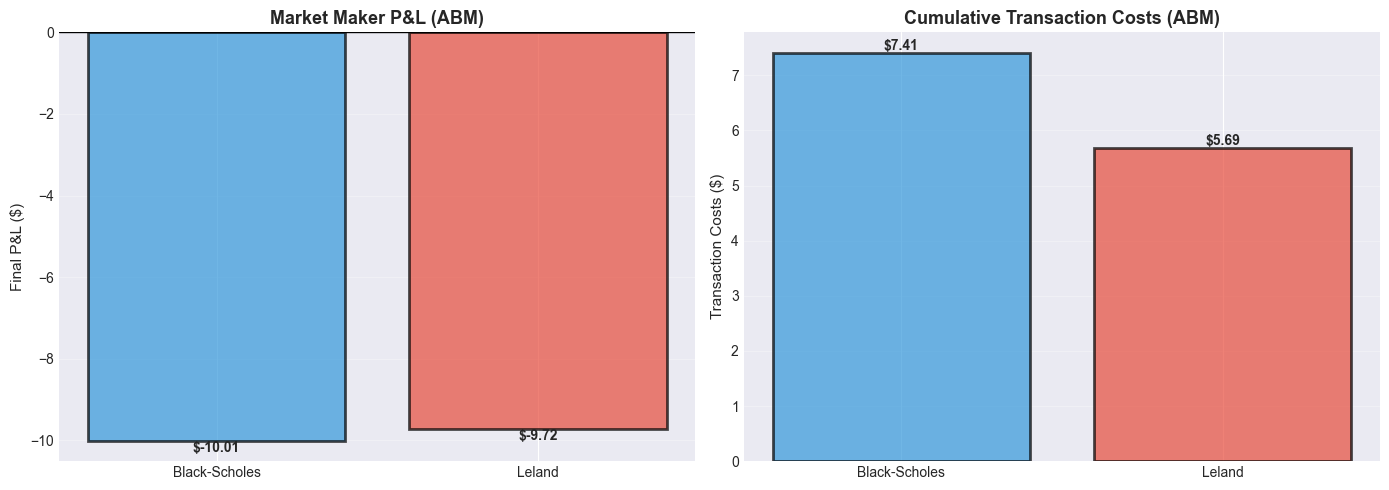

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Final P&L
ax1 = axes[0]
strategies = ['Black-Scholes', 'Leland']
pnls = [abm_results['market_makers']['BlackScholes']['final_pnl'],
        abm_results['market_makers']['Leland']['final_pnl']]
colors = ['#3498db', '#e74c3c']

bars = ax1.bar(strategies, pnls, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax1.set_ylabel('Final P&L ($)', fontsize=11)
ax1.set_title('Market Maker P&L (ABM)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

for bar, pnl in zip(bars, pnls):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'${pnl:.2f}',
            ha='center', va='bottom' if height > 0 else 'top',
            fontsize=10, fontweight='bold')

# Plot 2: Transaction Costs
ax2 = axes[1]
tcs = [abm_results['market_makers']['BlackScholes']['transaction_costs'],
       abm_results['market_makers']['Leland']['transaction_costs']]

bars = ax2.bar(strategies, tcs, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_ylabel('Transaction Costs ($)', fontsize=11)
ax2.set_title('Cumulative Transaction Costs (ABM)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

for bar, tc in zip(bars, tcs):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'${tc:.2f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 3.3 ABM: P&L Evolution Over Time

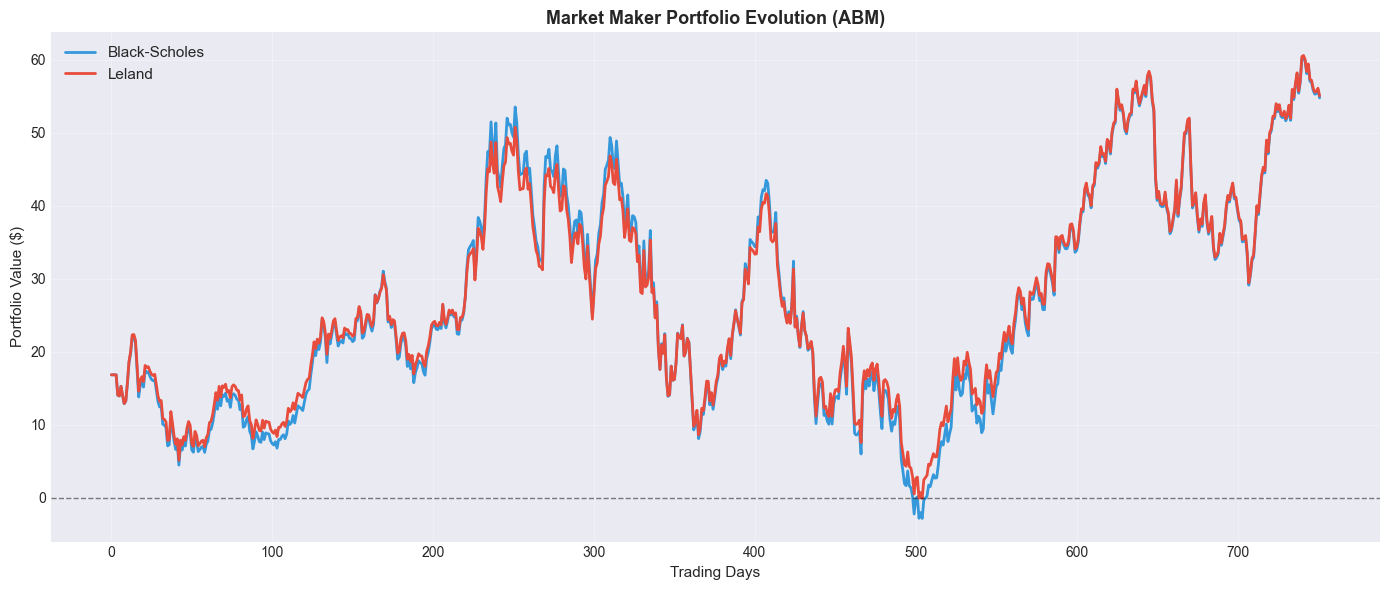

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

bs_pnl = abm_results['market_makers']['BlackScholes']['pnl_history']
leland_pnl = abm_results['market_makers']['Leland']['pnl_history']

ax.plot(bs_pnl, label='Black-Scholes', color='#3498db', linewidth=2)
ax.plot(leland_pnl, label='Leland', color='#e74c3c', linewidth=2)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

ax.set_xlabel('Trading Days', fontsize=11)
ax.set_ylabel('Portfolio Value ($)', fontsize=11)
ax.set_title('Market Maker Portfolio Evolution (ABM)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.4 Monte Carlo: Risk-Return Plot

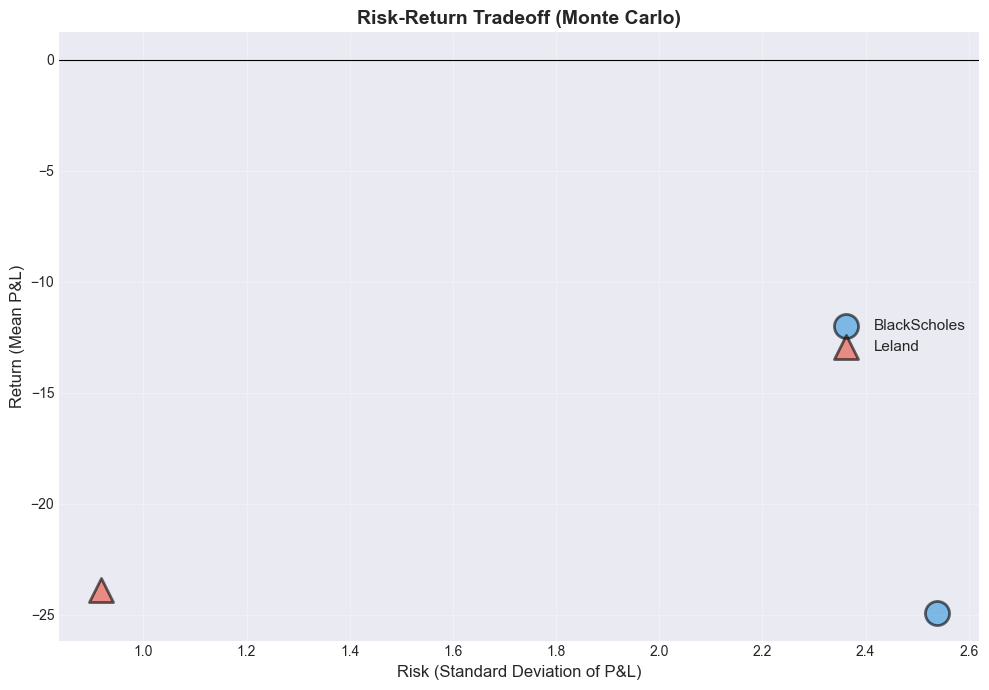

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))

strategies = ['BlackScholes', 'Leland']
colors = ['#3498db', '#e74c3c']
markers = ['o', '^']

for strategy, color, marker in zip(strategies, colors, markers):
    data = mc_results['strategies'][strategy]
    ax.scatter(data['std_pnl'], data['mean_pnl'], 
              s=300, c=color, alpha=0.6, edgecolors='black', 
              linewidth=2, marker=marker, label=strategy)

ax.set_xlabel('Risk (Standard Deviation of P&L)', fontsize=12)
ax.set_ylabel('Return (Mean P&L)', fontsize=12)
ax.set_title('Risk-Return Tradeoff (Monte Carlo)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
plt.show()

### 3.5 Monte Carlo: P&L Distribution

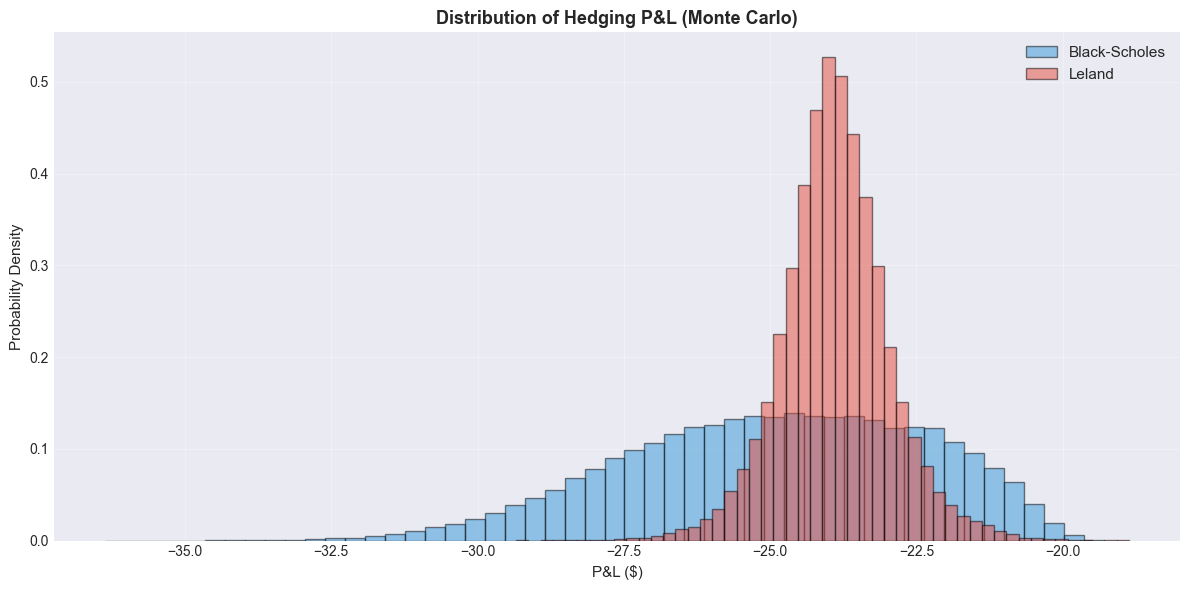

Black-Scholes: Mean=$-24.91, Std=$2.54
Leland:        Mean=$-23.89, Std=$0.92


In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

bs_errors = mc_results['strategies']['BlackScholes']['errors']
leland_errors = mc_results['strategies']['Leland']['errors']

ax.hist(bs_errors, bins=50, alpha=0.5, label='Black-Scholes', 
       color='#3498db', edgecolor='black', density=True)
ax.hist(leland_errors, bins=50, alpha=0.5, label='Leland', 
       color='#e74c3c', edgecolor='black', density=True)

ax.set_xlabel('P&L ($)', fontsize=11)
ax.set_ylabel('Probability Density', fontsize=11)
ax.set_title('Distribution of Hedging P&L (Monte Carlo)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Black-Scholes: Mean=${np.mean(bs_errors):.2f}, Std=${np.std(bs_errors):.2f}")
print(f"Leland:        Mean=${np.mean(leland_errors):.2f}, Std=${np.std(leland_errors):.2f}")

### 3.6 ABM vs Monte Carlo Comparison

In [10]:
# Comparison table
compare_abm_vs_mc(abm_results, mc_results)


                    ABM vs MONTE CARLO COMPARISON

Metric                         ABM (Real Data)      Monte Carlo         
----------------------------------------------------------------------
BLACK-SCHOLES:
  P&L                          $  -10.01          $  -24.91
  Transaction Costs            $    7.41          $    7.00

LELAND:
  P&L                          $   -9.72          $  -23.89
  Transaction Costs            $    5.69          $    6.02
----------------------------------------------------------------------

Leland Advantage:
  ABM (Real):       $    0.29
  Monte Carlo:      $    1.02

✓ Leland is better in BOTH real data AND simulations!



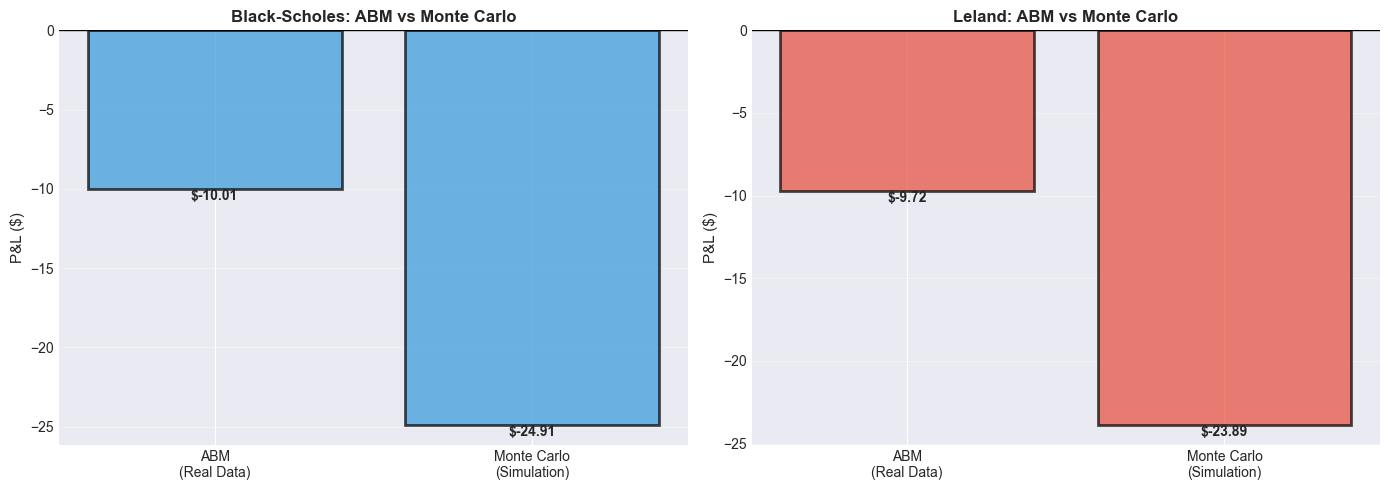

In [11]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Black-Scholes
ax1 = axes[0]
models = ['ABM\n(Real Data)', 'Monte Carlo\n(Simulation)']
bs_pnls = [abm_results['market_makers']['BlackScholes']['final_pnl'],
          mc_results['strategies']['BlackScholes']['mean_pnl']]

bars = ax1.bar(models, bs_pnls, color='#3498db', alpha=0.7, edgecolor='black', linewidth=2)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax1.set_ylabel('P&L ($)', fontsize=11)
ax1.set_title('Black-Scholes: ABM vs Monte Carlo', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

for bar, pnl in zip(bars, bs_pnls):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'${pnl:.2f}', ha='center', va='bottom' if height > 0 else 'top',
            fontsize=10, fontweight='bold')

# Leland
ax2 = axes[1]
leland_pnls = [abm_results['market_makers']['Leland']['final_pnl'],
              mc_results['strategies']['Leland']['mean_pnl']]

bars = ax2.bar(models, leland_pnls, color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=2)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_ylabel('P&L ($)', fontsize=11)
ax2.set_title('Leland: ABM vs Monte Carlo', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

for bar, pnl in zip(bars, leland_pnls):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'${pnl:.2f}', ha='center', va='bottom' if height > 0 else 'top',
            fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Export Results

In [12]:
from analysis import export_results_to_csv

export_results_to_csv(abm_results, mc_results, 'results_summary.csv')
print("Results exported to 'results_summary.csv'")

✓ Results exported to results_summary.csv
Results exported to 'results_summary.csv'


## Summary

This notebook compared:
1. **ABM with real market data** - shows how strategies perform on actual historical prices
2. **Monte Carlo simulation** - shows theoretical performance under GBM assumption
3. **Black-Scholes vs Leland** - comparison of standard and modified volatility approaches

Key findings:
- Leland's modified volatility typically reduces transaction costs
- Performance depends on market conditions (trending vs mean-reverting)
- ABM with real data provides more realistic assessment